In [1]:
import xarray as xr
import numpy as np
import os
import glob
import pandas as pd
import dask.array as da
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec
from scipy.stats import pearsonr
import xskillscore as xs
from dask.diagnostics import ProgressBar
from scipy.stats import chi2_contingency

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colorbar import ColorbarBase

import warnings
warnings.filterwarnings("ignore", message="invalid value encountered in divide")

In [2]:
GPCC = sorted(glob.glob(f'/g/data/ia39/aus-ref-clim-data-nci/gpcc/data/full_data_monthly_v2022/g10/*.nc'))

# Combine the NetCDF files
P = xr.open_mfdataset(GPCC, parallel=True,combine='by_coords')
P = P.compute()

In [3]:
Tmax = xr.open_dataset("/g/data/w40/nt4273/Data/BEST/Complete_TMAX_LatLong1.nc")

In [4]:
#Climatology
Tmax_Clim = Tmax.climatology

In [5]:
# Assuming P is your xarray Dataset or DataArray
# Extract the time array
P = P.sel(lat=P.lat[::-1])
P = P.rename({'lat': 'latitude', 'lon': 'longitude'})
time_array = P.time.values

# Convert to pandas DatetimeIndex
datetime_index = pd.DatetimeIndex(time_array)

# Generate end-of-month dates
end_of_month_dates = datetime_index.to_period('M').to_timestamp('M')

# Convert back to numpy array
end_of_month_array = end_of_month_dates.to_numpy()

# Update the time array in the dataset P
if isinstance(P, xr.DataArray):
    P = P.assign_coords(time=('time', end_of_month_array))
elif isinstance(P, xr.Dataset):
    P = P.assign_coords(time=('time', end_of_month_array))

In [6]:
#As the BEST data time is in float64 so convert this to datetime64 format
Best_Tmax_modT = pd.date_range(start='1850-01-31', periods = len(Tmax['time']), freq = 'ME')
Tmax['time'] = Best_Tmax_modT

In [7]:
P = P.sel(time = slice("1940-01-31T00:00:00.000000000","2020-12-31T00:00:00.000000000"))
Tmax = Tmax.sel(time = slice("1940-01-31T00:00:00.000000000","2020-12-31T00:00:00.000000000"))

In [8]:
#Tmax
Jan = Tmax.temperature.sel(time = Tmax['time.month'] == 1) + Tmax_Clim[0,:,:]
Feb = Tmax.temperature.sel(time = Tmax['time.month'] == 2) + Tmax_Clim[1,:,:]
Mar = Tmax.temperature.sel(time = Tmax['time.month'] == 3) + Tmax_Clim[2,:,:]
Apr = Tmax.temperature.sel(time = Tmax['time.month'] == 4) + Tmax_Clim[3,:,:]
May = Tmax.temperature.sel(time = Tmax['time.month'] == 5) + Tmax_Clim[4,:,:]
Jun = Tmax.temperature.sel(time = Tmax['time.month'] == 6) + Tmax_Clim[5,:,:]
Jul = Tmax.temperature.sel(time = Tmax['time.month'] == 7) + Tmax_Clim[6,:,:]
Aug = Tmax.temperature.sel(time = Tmax['time.month'] == 8) + Tmax_Clim[7,:,:]
Sep = Tmax.temperature.sel(time = Tmax['time.month'] == 9) + Tmax_Clim[8,:,:]
Oct = Tmax.temperature.sel(time = Tmax['time.month'] == 10) + Tmax_Clim[9,:,:]
Nov = Tmax.temperature.sel(time = Tmax['time.month'] == 11) + Tmax_Clim[10,:,:]
Dec = Tmax.temperature.sel(time = Tmax['time.month'] == 12) + Tmax_Clim[11,:,:]

#Precipitation
Jan2 = P.precip.sel(time = P['time.month'] == 1)
Feb2 = P.precip.sel(time = P['time.month'] == 2)
Mar2 = P.precip.sel(time = P['time.month'] == 3)
Apr2 = P.precip.sel(time = P['time.month'] == 4)
May2 = P.precip.sel(time = P['time.month'] == 5)
Jun2 = P.precip.sel(time = P['time.month'] == 6)
Jul2 = P.precip.sel(time = P['time.month'] == 7)
Aug2 = P.precip.sel(time = P['time.month'] == 8)
Sep2 = P.precip.sel(time = P['time.month'] == 9)
Oct2 = P.precip.sel(time = P['time.month'] == 10)
Nov2 = P.precip.sel(time = P['time.month'] == 11)
Dec2 = P.precip.sel(time = P['time.month'] == 12)

In [9]:
rolling_Tmax_Jan = Jan.rolling(time=15, center=True).mean()
rolling_Tmax_Feb = Feb.rolling(time=15, center=True).mean()
rolling_Tmax_Mar = Mar.rolling(time=15, center=True).mean()
rolling_Tmax_Apr = Apr.rolling(time=15, center=True).mean()
rolling_Tmax_May = May.rolling(time=15, center=True).mean()
rolling_Tmax_Jun = Jun.rolling(time=15, center=True).mean()
rolling_Tmax_Jul = Jul.rolling(time=15, center=True).mean()
rolling_Tmax_Aug = Aug.rolling(time=15, center=True).mean()
rolling_Tmax_Sep = Sep.rolling(time=15, center=True).mean()
rolling_Tmax_Oct = Oct.rolling(time=15, center=True).mean()
rolling_Tmax_Nov = Nov.rolling(time=15, center=True).mean()
rolling_Tmax_Dec = Dec.rolling(time=15, center=True).mean()

In [10]:
R_Jan = Jan - rolling_Tmax_Jan
R_Feb = Feb - rolling_Tmax_Feb
R_Mar = Mar - rolling_Tmax_Mar
R_Apr = Apr - rolling_Tmax_Apr
R_May = May - rolling_Tmax_May
R_Jun = Jun - rolling_Tmax_Jun
R_Jul = Jul - rolling_Tmax_Jul
R_Aug = Aug - rolling_Tmax_Aug
R_Sep = Sep - rolling_Tmax_Sep
R_Oct = Oct - rolling_Tmax_Oct
R_Nov = Nov - rolling_Tmax_Nov
R_Dec = Dec - rolling_Tmax_Dec

In [11]:
rolling_P_Jan2 = Jan2.rolling(time=15, center=True).mean()
rolling_P_Feb2 = Feb2.rolling(time=15, center=True).mean()
rolling_P_Mar2 = Mar2.rolling(time=15, center=True).mean()
rolling_P_Apr2 = Apr2.rolling(time=15, center=True).mean()
rolling_P_May2 = May2.rolling(time=15, center=True).mean()
rolling_P_Jun2 = Jun2.rolling(time=15, center=True).mean()
rolling_P_Jul2 = Jul2.rolling(time=15, center=True).mean()
rolling_P_Aug2 = Aug2.rolling(time=15, center=True).mean()
rolling_P_Sep2 = Sep2.rolling(time=15, center=True).mean()
rolling_P_Oct2 = Oct2.rolling(time=15, center=True).mean()
rolling_P_Nov2 = Nov2.rolling(time=15, center=True).mean()
rolling_P_Dec2 = Dec2.rolling(time=15, center=True).mean()

In [12]:
R_Jan2 = Jan2 - rolling_P_Jan2
R_Feb2 = Feb2 - rolling_P_Feb2
R_Mar2 = Mar2 - rolling_P_Mar2
R_Apr2 = Apr2 - rolling_P_Apr2
R_May2 = May2 - rolling_P_May2
R_Jun2 = Jun2 - rolling_P_Jun2
R_Jul2 = Jul2 - rolling_P_Jul2
R_Aug2 = Aug2 - rolling_P_Aug2
R_Sep2 = Sep2 - rolling_P_Sep2
R_Oct2 = Oct2 - rolling_P_Oct2
R_Nov2 = Nov2 - rolling_P_Nov2
R_Dec2 = Dec2 - rolling_P_Dec2

In [13]:
# List of months
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Loop through each month
for month in months:
    # Construct the variable names dynamically
    R_month = globals()[f'R_{month}']
    R_month2 = globals()[f'R_{month}2']
    
    # Create a mask where both are not NaN
    mask = (~R_month.isnull()) & (~R_month2.isnull())
    
    # Apply the mask to both DataArrays, keeping the same names
    globals()[f'R_{month}'] = R_month.where(mask, drop=True)
    globals()[f'R_{month}2'] = R_month2.where(mask, drop=True)

<b> Original 75th and 25th </b>

In [14]:
# Define percentiles
temp_percentileHD = 75
precip_percentileHD = 25

# Function to calculate concurrent events for a single grid point
def count_concurrent_eventsHD(temperature, precipitation, temp_percentileHD, precip_percentileHD):
    temp_threshold = np.percentile(temperature, temp_percentileHD)
    precip_threshold = np.percentile(precipitation, precip_percentileHD)
    event_countHD = np.sum((temperature > temp_threshold) & (precipitation < precip_threshold))
    return event_countHD

# Apply the function over the latitude and longitude dimensions
def apply_count_concurrent_eventsHD(temperature,precipitation, temp_percentileHD, precip_percentileHD):
    return xr.apply_ufunc(
        count_concurrent_eventsHD, temperature, precipitation,
        input_core_dims=[['time'], ['time']],
        kwargs={'temp_percentileHD': temp_percentileHD, 'precip_percentileHD': precip_percentileHD},
        vectorize=True,
        dask='parallelized',
        output_dtypes=[int]
    )

In [15]:
countJan_HD = apply_count_concurrent_eventsHD(R_Jan, R_Jan2, temp_percentileHD, precip_percentileHD)
countFeb_HD = apply_count_concurrent_eventsHD(R_Feb, R_Feb2, temp_percentileHD, precip_percentileHD)
countMar_HD = apply_count_concurrent_eventsHD(R_Mar, R_Mar2, temp_percentileHD, precip_percentileHD)
countApr_HD = apply_count_concurrent_eventsHD(R_Apr, R_Apr2, temp_percentileHD, precip_percentileHD)
countMay_HD = apply_count_concurrent_eventsHD(R_May, R_May2, temp_percentileHD, precip_percentileHD)
countJun_HD = apply_count_concurrent_eventsHD(R_Jun, R_Jun2, temp_percentileHD, precip_percentileHD)
countJul_HD = apply_count_concurrent_eventsHD(R_Jul, R_Jul2, temp_percentileHD, precip_percentileHD)
countAug_HD = apply_count_concurrent_eventsHD(R_Aug, R_Aug2, temp_percentileHD, precip_percentileHD)
countSep_HD = apply_count_concurrent_eventsHD(R_Sep, R_Sep2, temp_percentileHD, precip_percentileHD)
countOct_HD = apply_count_concurrent_eventsHD(R_Oct, R_Oct2, temp_percentileHD, precip_percentileHD)
countNov_HD = apply_count_concurrent_eventsHD(R_Nov, R_Nov2, temp_percentileHD, precip_percentileHD)
countDec_HD = apply_count_concurrent_eventsHD(R_Dec, R_Dec2, temp_percentileHD, precip_percentileHD)

In [16]:
R_Jan

<xarray.DataArray (time: 67, latitude: 140, longitude: 360)> Size: 14MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * latitude   (latitude) float32 560B -55.5 -54.5 -53.5 ... 81.5 82.5 83.5
  * time       (time) datetime64[ns] 536B 1947-01-31 1948-01-31 ... 2013-01-31

In [17]:
#Ratio
BC = 0.25*0.25 ###Considering 75th percentile

#JanHD
FrequencyJanHD = countJan_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioJanHD = FrequencyJanHD/BC

#FebHD
FrequencyFebHD = countFeb_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioFebHD = FrequencyFebHD/BC

#MarHD
FrequencyMarHD = countMar_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioMarHD = FrequencyMarHD/BC

#AprHD
FrequencyAprHD = countApr_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioAprHD = FrequencyAprHD/BC

#MayHD
FrequencyMayHD = countMay_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioMayHD = FrequencyMayHD/BC

#JunHD
FrequencyJunHD = countJun_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioJunHD = FrequencyJunHD/BC

#JulyHD
FrequencyJulHD = countJul_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioJulHD = FrequencyJulHD/BC

#AugHD
FrequencyAugHD = countAug_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioAugHD = FrequencyAugHD/BC

#SepHD
FrequencySepHD = countSep_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioSepHD = FrequencySepHD/BC

#OctHD
FrequencyOctHD = countOct_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioOctHD = FrequencyOctHD/BC

#NovHD
FrequencyNovHD = countNov_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioNovHD = FrequencyNovHD/BC

#DecHD
FrequencyDecHD = countDec_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioDecHD = FrequencyDecHD/BC

In [18]:
def count_concurrent_events_HD_chisquare(temperature, precipitation, temp_percentileHD, precip_percentileHD):
    
        temp_threshold = np.percentile(temperature, temp_percentileHD)
        precip_threshold = np.percentile(precipitation, precip_percentileHD)

        is_hot = temperature > temp_threshold
        is_dry = precipitation < precip_threshold

        HD = np.sum(is_hot & is_dry)
        HnD = np.sum(is_hot & ~is_dry)
        nHD = np.sum(~is_hot & is_dry)
        nHnD = np.sum(~is_hot & ~is_dry)


        observed = np.array([[HD, HnD], [nHD, nHnD]])
        try:
            _, p, _, _ = chi2_contingency(observed)
        except ValueError:
            p = np.nan
               

        return p

def apply_chi_square_to_grid(temperature_data, precipitation_data, temp_percentileHD, precip_percentileHD):
    # Apply the chi-square function to each grid point
    results = xr.apply_ufunc(
        count_concurrent_events_HD_chisquare, 
        temperature_data, precipitation_data, 
        input_core_dims = [['time'], ['time']], 
        kwargs={'temp_percentileHD': temp_percentileHD, 'precip_percentileHD': precip_percentileHD},
        vectorize=True, 
        dask='parallelized',
        output_dtypes=[float]
    )
    
    return results

In [19]:
with ProgressBar():
    p_Jan = apply_chi_square_to_grid(R_Jan, R_Jan2, temp_percentileHD, precip_percentileHD)
    p_Feb = apply_chi_square_to_grid(R_Feb, R_Feb2, temp_percentileHD, precip_percentileHD)
    p_Mar = apply_chi_square_to_grid(R_Mar, R_Mar2, temp_percentileHD, precip_percentileHD)
    p_Apr = apply_chi_square_to_grid(R_Apr, R_Apr2, temp_percentileHD, precip_percentileHD)
    p_May = apply_chi_square_to_grid(R_May, R_May2, temp_percentileHD, precip_percentileHD)
    p_Jun = apply_chi_square_to_grid(R_Jun, R_Jun2, temp_percentileHD, precip_percentileHD)
    p_Jul = apply_chi_square_to_grid(R_Jul, R_Jul2, temp_percentileHD, precip_percentileHD)
    p_Aug = apply_chi_square_to_grid(R_Aug, R_Aug2, temp_percentileHD, precip_percentileHD)
    p_Sep = apply_chi_square_to_grid(R_Sep, R_Sep2, temp_percentileHD, precip_percentileHD)
    p_Oct = apply_chi_square_to_grid(R_Oct, R_Oct2, temp_percentileHD, precip_percentileHD)
    p_Nov = apply_chi_square_to_grid(R_Nov, R_Nov2, temp_percentileHD, precip_percentileHD)
    p_Dec = apply_chi_square_to_grid(R_Dec, R_Dec2, temp_percentileHD, precip_percentileHD)

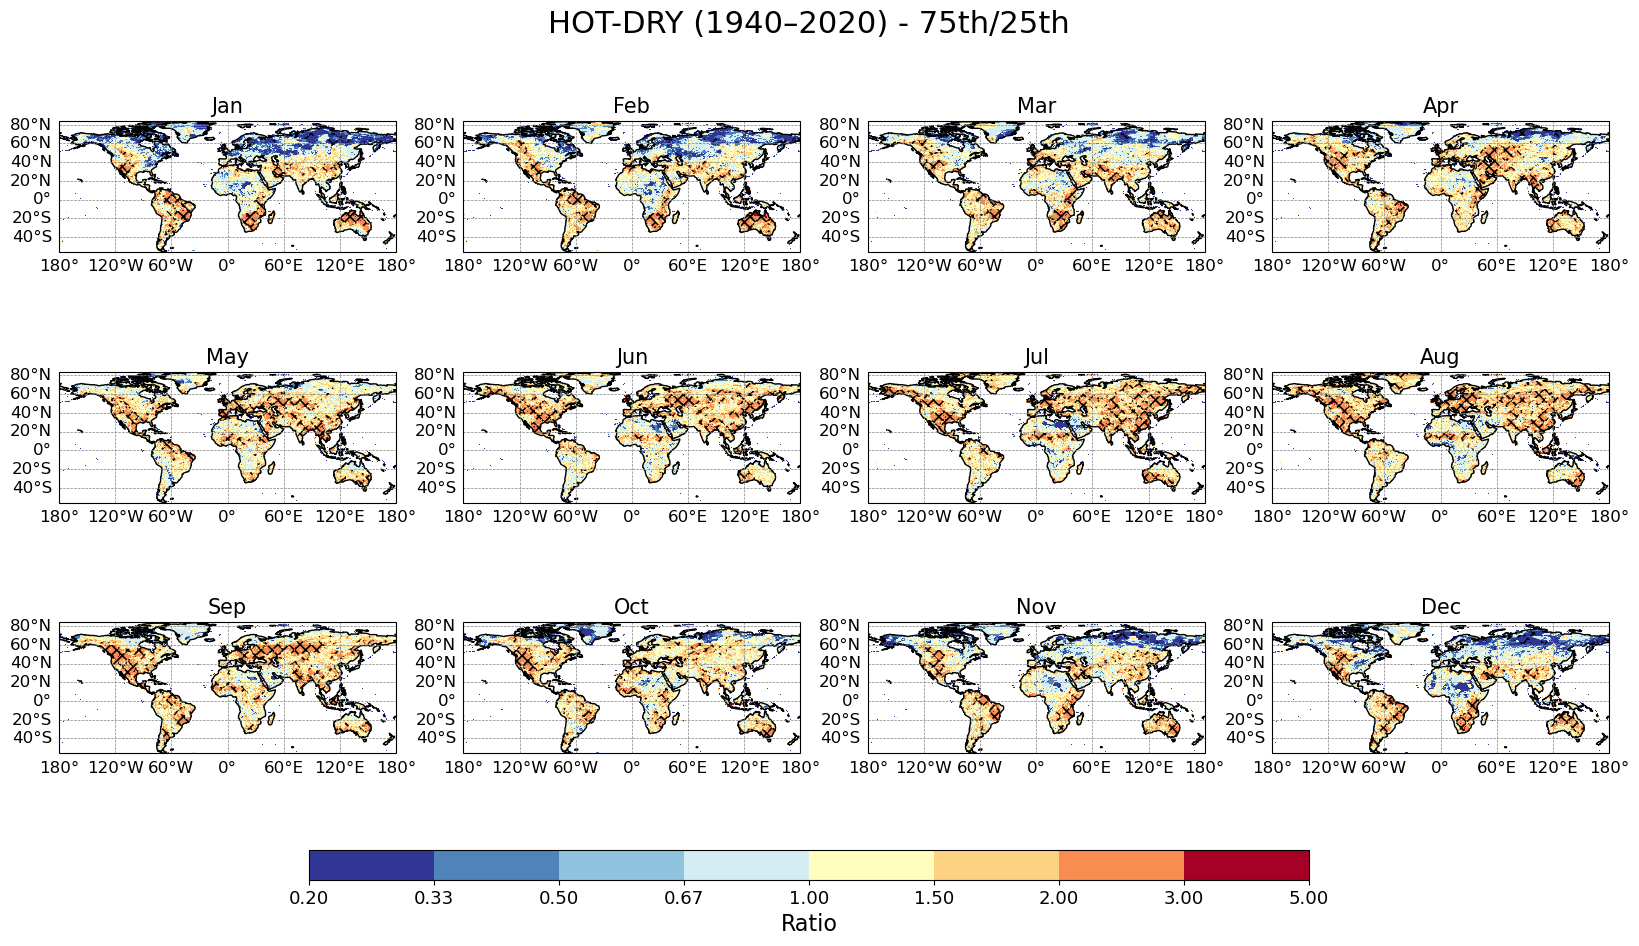

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs

plt.rcParams['hatch.linewidth'] = 1.2 
# Define the custom colors and boundaries (lowest bound is 0.2)
colors = ['#313695', '#5183bb', '#90c3dd', '#d4edf4', '#fffebe',
          '#fed283', '#f88c51', '#dd3d2d', '#a50026']
bounds = [0.2, 0.33, 0.5, 0.67, 1, 1.5, 2, 3, 5]

# Create a custom colormap and norm using fixed bounds
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=bounds, ncolors=len(colors))

# Ensure land_mask matches the spatial resolution of the data
land_mask = Tmax.land_mask.interp(latitude=RatioJanHD.latitude, method="nearest")

# Your monthly data and p-values lists
Ratio_list1 = [RatioJanHD, RatioFebHD, RatioMarHD, RatioAprHD, RatioMayHD, RatioJunHD,
               RatioJulHD, RatioAugHD, RatioSepHD, RatioOctHD, RatioNovHD, RatioDecHD]
p_values_list = [p_Jan, p_Feb, p_Mar, p_Apr, p_May, p_Jun,
                 p_Jul, p_Aug, p_Sep, p_Oct, p_Nov, p_Dec]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create figure with GridSpec layout
fig = plt.figure(figsize=(20, 15))
gs = GridSpec(3, 4, figure=fig, wspace=0.2, hspace=-0.8)

for i, (ratio, p_vals, month) in enumerate(zip(Ratio_list1, p_values_list, months)):
    ax = fig.add_subplot(gs[i], projection=ccrs.PlateCarree())
    
    # Resample land_mask to match ratio latitudes
    land_mask_resampled = land_mask.sel(latitude=ratio.latitude, method="nearest")
    latitudes_2d = np.broadcast_to(ratio.latitude.values[:, np.newaxis], ratio.shape)
    
    # Mask oceans and Antarctica (keep land and lat > -60)
    masked_ratio = ratio.where((land_mask_resampled != 0) & (latitudes_2d > -60))
    
    # Plot ratio data with fixed cmap and norm, no colorbar yet
    im = masked_ratio.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, add_colorbar=False)
    
    # Overlay hatching for significant p-values
    sig = (p_vals < 0.05) & (land_mask_resampled != 0) & (latitudes_2d > -60)
    lons, lats = np.meshgrid(ratio.longitude, ratio.latitude)
    sig_mask = sig.where(sig, other=np.nan)
    ax.contourf(lons, lats, sig_mask, hatches=['xxx'], colors='none', transform=ccrs.PlateCarree(), zorder=20)
    
    # Add coastlines and title
    ax.coastlines()
    ax.set_title(month, fontsize=15)
    
    # Configure gridlines
    gridlines = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                             linewidth=0.5, color='gray', linestyle='--')
    gridlines.top_labels = False
    gridlines.right_labels = False
    gridlines.xlabels_bottom = True
    gridlines.ylabels_left = True
    gridlines.xlabel_style = {'size': 12}
    gridlines.ylabel_style = {'size': 12}

# Add horizontal colorbar below the subplots
cax = fig.add_axes([0.25, 0.4, 0.5, 0.02])  # Adjust position as needed
cax.tick_params(axis='x', rotation=0, labelsize=13)
cb = ColorbarBase(cax, cmap=cmap, norm=norm, orientation='horizontal', ticks=bounds)
cb.set_label('Ratio', fontsize=16)

# Main title and layout adjustments
fig.suptitle('HOT-DRY (1940–2020) - 75th/25th', fontsize=22)
fig.subplots_adjust(top=1.28)

# Save or show figure
#fig.savefig('/g/data/gb02/nt4273/Confirmation_Plots/Obs_LMF_Sig_HOT-DRY_1940-2020_updated.png', bbox_inches='tight', dpi=300)
plt.show()

<b>  85th and 15th </b>

In [47]:
# Define percentiles
temp_percentileHD = 85
precip_percentileHD = 15

# Function to calculate concurrent events for a single grid point
def count_concurrent_eventsHD(temperature, precipitation, temp_percentileHD, precip_percentileHD):
    temp_threshold = np.percentile(temperature, temp_percentileHD)
    precip_threshold = np.percentile(precipitation, precip_percentileHD)
    event_countHD = np.sum((temperature > temp_threshold) & (precipitation < precip_threshold))
    return event_countHD

# Apply the function over the latitude and longitude dimensions
def apply_count_concurrent_eventsHD(temperature,precipitation, temp_percentileHD, precip_percentileHD):
    return xr.apply_ufunc(
        count_concurrent_eventsHD, temperature, precipitation,
        input_core_dims=[['time'], ['time']],
        kwargs={'temp_percentileHD': temp_percentileHD, 'precip_percentileHD': precip_percentileHD},
        vectorize=True,
        dask='parallelized',
        output_dtypes=[int]
    )

In [48]:
countJan_HD = apply_count_concurrent_eventsHD(R_Jan, R_Jan2, temp_percentileHD, precip_percentileHD)
countFeb_HD = apply_count_concurrent_eventsHD(R_Feb, R_Feb2, temp_percentileHD, precip_percentileHD)
countMar_HD = apply_count_concurrent_eventsHD(R_Mar, R_Mar2, temp_percentileHD, precip_percentileHD)
countApr_HD = apply_count_concurrent_eventsHD(R_Apr, R_Apr2, temp_percentileHD, precip_percentileHD)
countMay_HD = apply_count_concurrent_eventsHD(R_May, R_May2, temp_percentileHD, precip_percentileHD)
countJun_HD = apply_count_concurrent_eventsHD(R_Jun, R_Jun2, temp_percentileHD, precip_percentileHD)
countJul_HD = apply_count_concurrent_eventsHD(R_Jul, R_Jul2, temp_percentileHD, precip_percentileHD)
countAug_HD = apply_count_concurrent_eventsHD(R_Aug, R_Aug2, temp_percentileHD, precip_percentileHD)
countSep_HD = apply_count_concurrent_eventsHD(R_Sep, R_Sep2, temp_percentileHD, precip_percentileHD)
countOct_HD = apply_count_concurrent_eventsHD(R_Oct, R_Oct2, temp_percentileHD, precip_percentileHD)
countNov_HD = apply_count_concurrent_eventsHD(R_Nov, R_Nov2, temp_percentileHD, precip_percentileHD)
countDec_HD = apply_count_concurrent_eventsHD(R_Dec, R_Dec2, temp_percentileHD, precip_percentileHD)

In [49]:
#Ratio
BC = 0.25*0.25 ###Considering 75th percentile

#JanHD
FrequencyJanHD = countJan_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioJanHD = FrequencyJanHD/BC

#FebHD
FrequencyFebHD = countFeb_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioFebHD = FrequencyFebHD/BC

#MarHD
FrequencyMarHD = countMar_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioMarHD = FrequencyMarHD/BC

#AprHD
FrequencyAprHD = countApr_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioAprHD = FrequencyAprHD/BC

#MayHD
FrequencyMayHD = countMay_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioMayHD = FrequencyMayHD/BC

#JunHD
FrequencyJunHD = countJun_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioJunHD = FrequencyJunHD/BC

#JulyHD
FrequencyJulHD = countJul_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioJulHD = FrequencyJulHD/BC

#AugHD
FrequencyAugHD = countAug_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioAugHD = FrequencyAugHD/BC

#SepHD
FrequencySepHD = countSep_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioSepHD = FrequencySepHD/BC

#OctHD
FrequencyOctHD = countOct_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioOctHD = FrequencyOctHD/BC

#NovHD
FrequencyNovHD = countNov_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioNovHD = FrequencyNovHD/BC

#DecHD
FrequencyDecHD = countDec_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioDecHD = FrequencyDecHD/BC

In [50]:
RatioJanHD

<xarray.DataArray (latitude: 140, longitude: 360)> Size: 403kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * latitude   (latitude) float32 560B -55.5 -54.5 -53.5 ... 81.5 82.5 83.5

In [51]:
ratios = [
    RatioJanHD, RatioFebHD, RatioMarHD, RatioAprHD,
    RatioMayHD, RatioJunHD, RatioJulHD, RatioAugHD,
    RatioSepHD, RatioOctHD, RatioNovHD, RatioDecHD
]

In [52]:
print("Max:", np.max(ratios))
print("Min:", np.min(ratios))

Max: 2.1492537313432836
Min: 0.0


In [53]:
with ProgressBar():
    p_Jan = apply_chi_square_to_grid(R_Jan, R_Jan2, temp_percentileHD, precip_percentileHD)
    p_Feb = apply_chi_square_to_grid(R_Feb, R_Feb2, temp_percentileHD, precip_percentileHD)
    p_Mar = apply_chi_square_to_grid(R_Mar, R_Mar2, temp_percentileHD, precip_percentileHD)
    p_Apr = apply_chi_square_to_grid(R_Apr, R_Apr2, temp_percentileHD, precip_percentileHD)
    p_May = apply_chi_square_to_grid(R_May, R_May2, temp_percentileHD, precip_percentileHD)
    p_Jun = apply_chi_square_to_grid(R_Jun, R_Jun2, temp_percentileHD, precip_percentileHD)
    p_Jul = apply_chi_square_to_grid(R_Jul, R_Jul2, temp_percentileHD, precip_percentileHD)
    p_Aug = apply_chi_square_to_grid(R_Aug, R_Aug2, temp_percentileHD, precip_percentileHD)
    p_Sep = apply_chi_square_to_grid(R_Sep, R_Sep2, temp_percentileHD, precip_percentileHD)
    p_Oct = apply_chi_square_to_grid(R_Oct, R_Oct2, temp_percentileHD, precip_percentileHD)
    p_Nov = apply_chi_square_to_grid(R_Nov, R_Nov2, temp_percentileHD, precip_percentileHD)
    p_Dec = apply_chi_square_to_grid(R_Dec, R_Dec2, temp_percentileHD, precip_percentileHD)

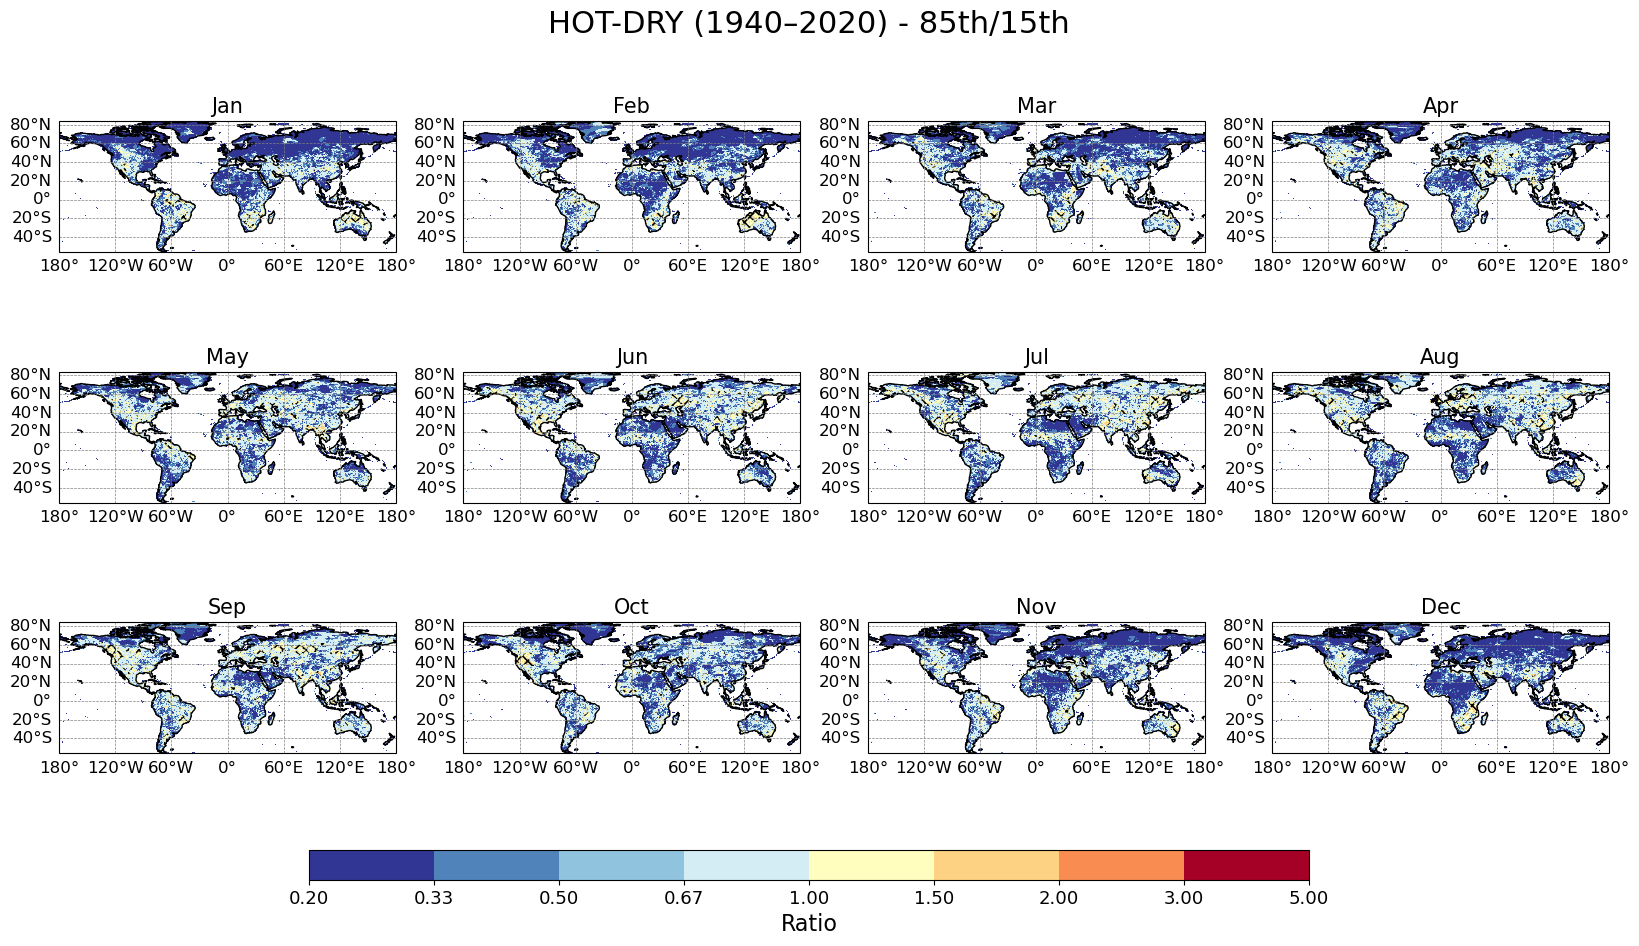

In [54]:
plt.rcParams['hatch.linewidth'] = 1.2 
# Define the custom colors and boundaries (lowest bound is 0.2)
colors = ['#313695', '#5183bb', '#90c3dd', '#d4edf4', '#fffebe',
          '#fed283', '#f88c51', '#dd3d2d', '#a50026']
bounds = [0.2, 0.33, 0.5, 0.67, 1, 1.5, 2, 3, 5]

# Create a custom colormap and norm using fixed bounds
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=bounds, ncolors=len(colors))

# Ensure land_mask matches the spatial resolution of the data
land_mask = Tmax.land_mask.interp(latitude=RatioJanHD.latitude, method="nearest")

# Your monthly data and p-values lists
Ratio_list1 = [RatioJanHD, RatioFebHD, RatioMarHD, RatioAprHD, RatioMayHD, RatioJunHD,
               RatioJulHD, RatioAugHD, RatioSepHD, RatioOctHD, RatioNovHD, RatioDecHD]
p_values_list = [p_Jan, p_Feb, p_Mar, p_Apr, p_May, p_Jun,
                 p_Jul, p_Aug, p_Sep, p_Oct, p_Nov, p_Dec]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create figure with GridSpec layout
fig = plt.figure(figsize=(20, 15))
gs = GridSpec(3, 4, figure=fig, wspace=0.2, hspace=-0.8)

for i, (ratio, p_vals, month) in enumerate(zip(Ratio_list1, p_values_list, months)):
    ax = fig.add_subplot(gs[i], projection=ccrs.PlateCarree())
    
    # Resample land_mask to match ratio latitudes
    land_mask_resampled = land_mask.sel(latitude=ratio.latitude, method="nearest")
    latitudes_2d = np.broadcast_to(ratio.latitude.values[:, np.newaxis], ratio.shape)
    
    # Mask oceans and Antarctica (keep land and lat > -60)
    masked_ratio = ratio.where((land_mask_resampled != 0) & (latitudes_2d > -60))
    
    # Plot ratio data with fixed cmap and norm, no colorbar yet
    im = masked_ratio.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, add_colorbar=False)
    
    # Overlay hatching for significant p-values
    sig = (p_vals < 0.05) & (land_mask_resampled != 0) & (latitudes_2d > -60)
    lons, lats = np.meshgrid(ratio.longitude, ratio.latitude)
    sig_mask = sig.where(sig, other=np.nan)
    ax.contourf(lons, lats, sig_mask, hatches=['xxx'], colors='none', transform=ccrs.PlateCarree(), zorder=20)
    
    # Add coastlines and title
    ax.coastlines()
    ax.set_title(month, fontsize=15)
    
    # Configure gridlines
    gridlines = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                             linewidth=0.5, color='gray', linestyle='--')
    gridlines.top_labels = False
    gridlines.right_labels = False
    gridlines.xlabels_bottom = True
    gridlines.ylabels_left = True
    gridlines.xlabel_style = {'size': 12}
    gridlines.ylabel_style = {'size': 12}

# Add horizontal colorbar below the subplots
cax = fig.add_axes([0.25, 0.4, 0.5, 0.02])  # Adjust position as needed
cax.tick_params(axis='x', rotation=0, labelsize=13)
cb = ColorbarBase(cax, cmap=cmap, norm=norm, orientation='horizontal', ticks=bounds)
cb.set_label('Ratio', fontsize=16)

# Main title and layout adjustments
fig.suptitle('HOT-DRY (1940–2020) - 85th/15th', fontsize=22)
fig.subplots_adjust(top=1.28)

# Save or show figure
fig.savefig('/g/data/gb02/nt4273/First_Paper/Sensitivity/Obs_LMF_Sig_HOT-DRY_1940-2020_85_15.png', bbox_inches='tight', dpi=300)
plt.show()

<b> 70th/30th </b>

In [55]:
# Define percentiles
temp_percentileHD = 70
precip_percentileHD = 30

# Function to calculate concurrent events for a single grid point
def count_concurrent_eventsHD(temperature, precipitation, temp_percentileHD, precip_percentileHD):
    temp_threshold = np.percentile(temperature, temp_percentileHD)
    precip_threshold = np.percentile(precipitation, precip_percentileHD)
    event_countHD = np.sum((temperature > temp_threshold) & (precipitation < precip_threshold))
    return event_countHD

# Apply the function over the latitude and longitude dimensions
def apply_count_concurrent_eventsHD(temperature,precipitation, temp_percentileHD, precip_percentileHD):
    return xr.apply_ufunc(
        count_concurrent_eventsHD, temperature, precipitation,
        input_core_dims=[['time'], ['time']],
        kwargs={'temp_percentileHD': temp_percentileHD, 'precip_percentileHD': precip_percentileHD},
        vectorize=True,
        dask='parallelized',
        output_dtypes=[int]
    )

In [56]:
countJan_HD = apply_count_concurrent_eventsHD(R_Jan, R_Jan2, temp_percentileHD, precip_percentileHD)
countFeb_HD = apply_count_concurrent_eventsHD(R_Feb, R_Feb2, temp_percentileHD, precip_percentileHD)
countMar_HD = apply_count_concurrent_eventsHD(R_Mar, R_Mar2, temp_percentileHD, precip_percentileHD)
countApr_HD = apply_count_concurrent_eventsHD(R_Apr, R_Apr2, temp_percentileHD, precip_percentileHD)
countMay_HD = apply_count_concurrent_eventsHD(R_May, R_May2, temp_percentileHD, precip_percentileHD)
countJun_HD = apply_count_concurrent_eventsHD(R_Jun, R_Jun2, temp_percentileHD, precip_percentileHD)
countJul_HD = apply_count_concurrent_eventsHD(R_Jul, R_Jul2, temp_percentileHD, precip_percentileHD)
countAug_HD = apply_count_concurrent_eventsHD(R_Aug, R_Aug2, temp_percentileHD, precip_percentileHD)
countSep_HD = apply_count_concurrent_eventsHD(R_Sep, R_Sep2, temp_percentileHD, precip_percentileHD)
countOct_HD = apply_count_concurrent_eventsHD(R_Oct, R_Oct2, temp_percentileHD, precip_percentileHD)
countNov_HD = apply_count_concurrent_eventsHD(R_Nov, R_Nov2, temp_percentileHD, precip_percentileHD)
countDec_HD = apply_count_concurrent_eventsHD(R_Dec, R_Dec2, temp_percentileHD, precip_percentileHD)

In [57]:
#Ratio
BC = 0.25*0.25 ###Considering 75th percentile

#JanHD
FrequencyJanHD = countJan_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioJanHD = FrequencyJanHD/BC

#FebHD
FrequencyFebHD = countFeb_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioFebHD = FrequencyFebHD/BC

#MarHD
FrequencyMarHD = countMar_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioMarHD = FrequencyMarHD/BC

#AprHD
FrequencyAprHD = countApr_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioAprHD = FrequencyAprHD/BC

#MayHD
FrequencyMayHD = countMay_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioMayHD = FrequencyMayHD/BC

#JunHD
FrequencyJunHD = countJun_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioJunHD = FrequencyJunHD/BC

#JulyHD
FrequencyJulHD = countJul_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioJulHD = FrequencyJulHD/BC

#AugHD
FrequencyAugHD = countAug_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioAugHD = FrequencyAugHD/BC

#SepHD
FrequencySepHD = countSep_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioSepHD = FrequencySepHD/BC

#OctHD
FrequencyOctHD = countOct_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioOctHD = FrequencyOctHD/BC

#NovHD
FrequencyNovHD = countNov_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioNovHD = FrequencyNovHD/BC

#DecHD
FrequencyDecHD = countDec_HD/67  ###Proportion of Concurrent Extreme Events = Number of concurrent extreme events/Total events 
RatioDecHD = FrequencyDecHD/BC

In [58]:
with ProgressBar():
    p_Jan = apply_chi_square_to_grid(R_Jan, R_Jan2, temp_percentileHD, precip_percentileHD)
    p_Feb = apply_chi_square_to_grid(R_Feb, R_Feb2, temp_percentileHD, precip_percentileHD)
    p_Mar = apply_chi_square_to_grid(R_Mar, R_Mar2, temp_percentileHD, precip_percentileHD)
    p_Apr = apply_chi_square_to_grid(R_Apr, R_Apr2, temp_percentileHD, precip_percentileHD)
    p_May = apply_chi_square_to_grid(R_May, R_May2, temp_percentileHD, precip_percentileHD)
    p_Jun = apply_chi_square_to_grid(R_Jun, R_Jun2, temp_percentileHD, precip_percentileHD)
    p_Jul = apply_chi_square_to_grid(R_Jul, R_Jul2, temp_percentileHD, precip_percentileHD)
    p_Aug = apply_chi_square_to_grid(R_Aug, R_Aug2, temp_percentileHD, precip_percentileHD)
    p_Sep = apply_chi_square_to_grid(R_Sep, R_Sep2, temp_percentileHD, precip_percentileHD)
    p_Oct = apply_chi_square_to_grid(R_Oct, R_Oct2, temp_percentileHD, precip_percentileHD)
    p_Nov = apply_chi_square_to_grid(R_Nov, R_Nov2, temp_percentileHD, precip_percentileHD)
    p_Dec = apply_chi_square_to_grid(R_Dec, R_Dec2, temp_percentileHD, precip_percentileHD)

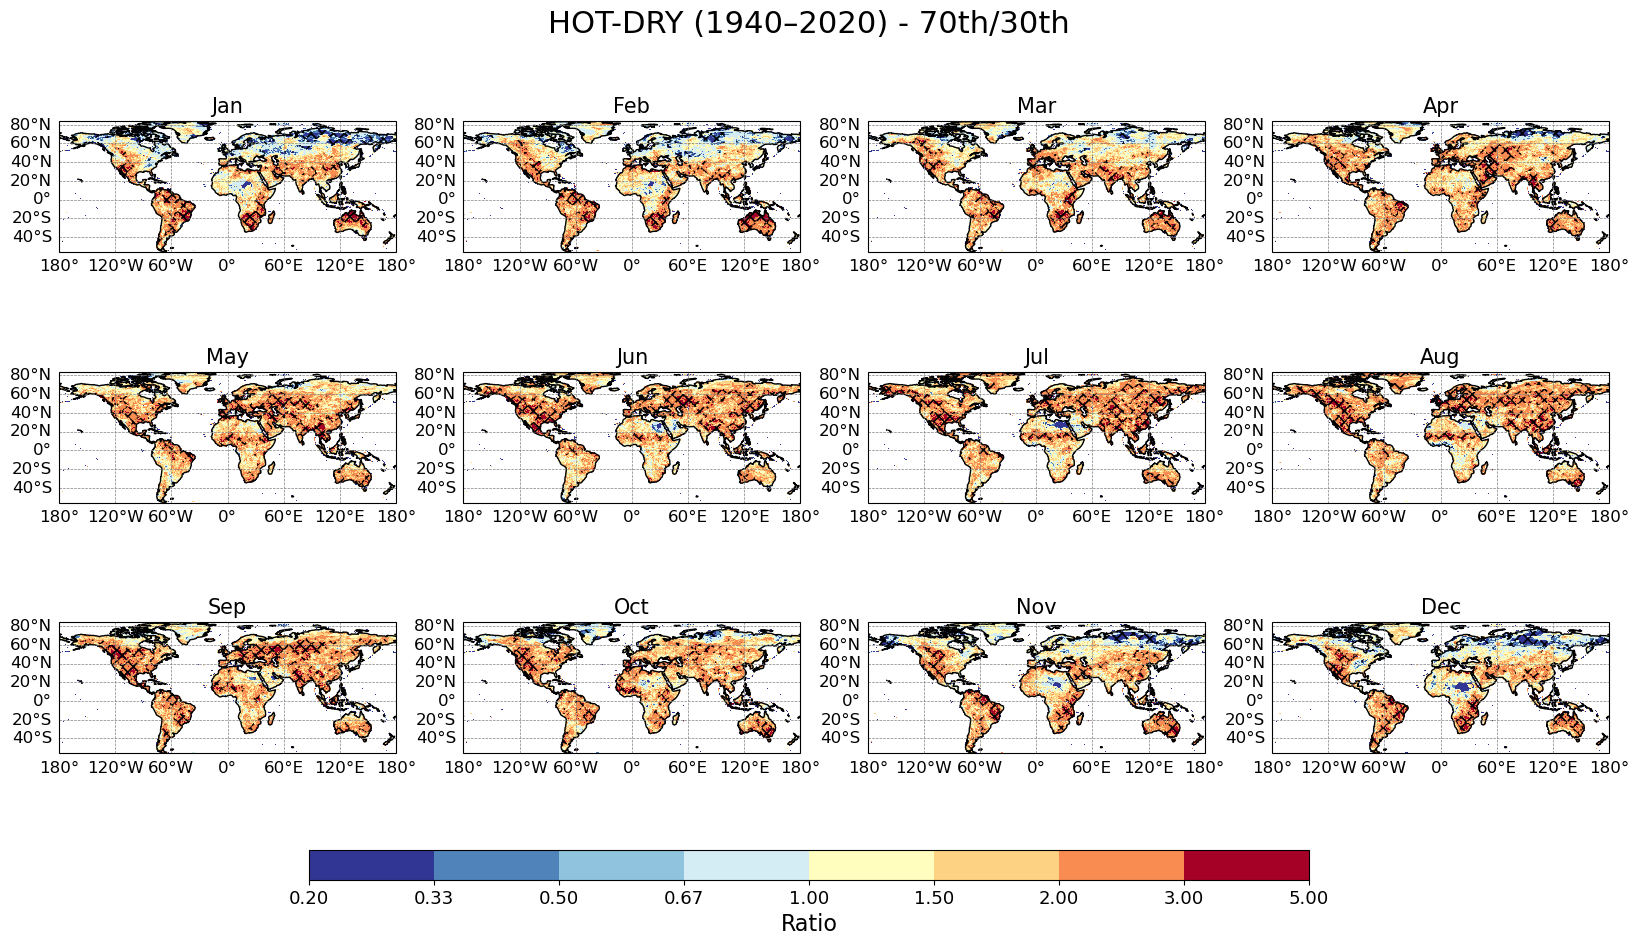

In [59]:
plt.rcParams['hatch.linewidth'] = 1.2 
# Define the custom colors and boundaries (lowest bound is 0.2)
colors = ['#313695', '#5183bb', '#90c3dd', '#d4edf4', '#fffebe',
          '#fed283', '#f88c51', '#dd3d2d', '#a50026']
bounds = [0.2, 0.33, 0.5, 0.67, 1, 1.5, 2, 3, 5]

# Create a custom colormap and norm using fixed bounds
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=bounds, ncolors=len(colors))

# Ensure land_mask matches the spatial resolution of the data
land_mask = Tmax.land_mask.interp(latitude=RatioJanHD.latitude, method="nearest")

# Your monthly data and p-values lists
Ratio_list1 = [RatioJanHD, RatioFebHD, RatioMarHD, RatioAprHD, RatioMayHD, RatioJunHD,
               RatioJulHD, RatioAugHD, RatioSepHD, RatioOctHD, RatioNovHD, RatioDecHD]
p_values_list = [p_Jan, p_Feb, p_Mar, p_Apr, p_May, p_Jun,
                 p_Jul, p_Aug, p_Sep, p_Oct, p_Nov, p_Dec]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create figure with GridSpec layout
fig = plt.figure(figsize=(20, 15))
gs = GridSpec(3, 4, figure=fig, wspace=0.2, hspace=-0.8)

for i, (ratio, p_vals, month) in enumerate(zip(Ratio_list1, p_values_list, months)):
    ax = fig.add_subplot(gs[i], projection=ccrs.PlateCarree())
    
    # Resample land_mask to match ratio latitudes
    land_mask_resampled = land_mask.sel(latitude=ratio.latitude, method="nearest")
    latitudes_2d = np.broadcast_to(ratio.latitude.values[:, np.newaxis], ratio.shape)
    
    # Mask oceans and Antarctica (keep land and lat > -60)
    masked_ratio = ratio.where((land_mask_resampled != 0) & (latitudes_2d > -60))
    
    # Plot ratio data with fixed cmap and norm, no colorbar yet
    im = masked_ratio.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, add_colorbar=False)
    
    # Overlay hatching for significant p-values
    sig = (p_vals < 0.05) & (land_mask_resampled != 0) & (latitudes_2d > -60)
    lons, lats = np.meshgrid(ratio.longitude, ratio.latitude)
    sig_mask = sig.where(sig, other=np.nan)
    ax.contourf(lons, lats, sig_mask, hatches=['xxx'], colors='none', transform=ccrs.PlateCarree(), zorder=20)
    
    # Add coastlines and title
    ax.coastlines()
    ax.set_title(month, fontsize=15)
    
    # Configure gridlines
    gridlines = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                             linewidth=0.5, color='gray', linestyle='--')
    gridlines.top_labels = False
    gridlines.right_labels = False
    gridlines.xlabels_bottom = True
    gridlines.ylabels_left = True
    gridlines.xlabel_style = {'size': 12}
    gridlines.ylabel_style = {'size': 12}

# Add horizontal colorbar below the subplots
cax = fig.add_axes([0.25, 0.4, 0.5, 0.02])  # Adjust position as needed
cax.tick_params(axis='x', rotation=0, labelsize=13)
cb = ColorbarBase(cax, cmap=cmap, norm=norm, orientation='horizontal', ticks=bounds)
cb.set_label('Ratio', fontsize=16)

# Main title and layout adjustments
fig.suptitle('HOT-DRY (1940–2020) - 70th/30th', fontsize=22)
fig.subplots_adjust(top=1.28)

# Save or show figure
fig.savefig('/g/data/gb02/nt4273/First_Paper/Sensitivity/Obs_LMF_Sig_HOT-DRY_1940-2020_70_30.png', bbox_inches='tight', dpi=300)
plt.show()